# Карта ДТП

https://dtp-stat.ru/pages/about/?ysclid=mqnzsthp1d506825474$0

Некоммерческий проект, посвящённый проблеме дорожно-транспортных происшествий в России.

«Карта ДТП» помогает выявлять реальные причины ДТП, оценивать уровень развития инфраструктуры, а также разрабатывать качественные решения и программы по повышению безопасности на улицах и дорогах.


## Оглавление

1. Цель и задачи исследования
   
   1.1. Описание данных
2. Сбор, загрузка и обработка данных по Кировской области

   2.1 Датафрейм ko - информация о ДТП в Кировской области

   2.2 Датафрейм participants_ko - информация об участниках ДТП в Кировской области

   2.3 Датафрейм vehicles_ko - информация о т/с в Кировской области

3. Сбор, загрузка и обработка данных по Московской области

   3.1 Датафрейм mo - информация о ДТП в Кировской области

   3.2

   3.3

4. Динамика ДТП по временным промежуткам в Кировской области

   4.1 График по месяцам и годам за весь период

   4.2 График по дням недели за весь период

   4.3 График по месяцам за весь период

   4.4 График по годам за весь период

5. Сравнение количества ДТП между группами водителей с разным стажем в Кировской области

6. Выводы

## 1. Цель и задачи исследования

В рамках проекта проводится анализ данных о дорожно-транспортных происшествиях

**Интервал исследования:**
С января 2015 года до августа 2024 года включительно (9 лет и 8 месяцев)

**Основная цель исследования** — оценить качество собранных данных, выявив возможные дубликаты и пропущенные значения, а также изучить ключевые закономерности в статистике ДТП.

**Задачи исследования:**

1) изучить динамику ДТП;

2) сравнить количество ДТП для групп водителей с разным стажем.

### 1.1 Описание данных

Данные `Kirovskaya_oblast.csv`, `Moscowskaya_oblast.csv` содержат информацию ДТП:

* `geometry.coordinates` — координаты ДТП;

* `id` — идентификатор ДТП;

*  `properties.tags` — тег происшествия;

*  `properties.light` — освещённость;

*  `properties.point.lat` — широта;

*  `properties.point.long` — долгота;

*  `properties.nearby` — ближайшие объекты;

*  `properties.region` — регион;

*  `properties.scheme` — схема ДТП;

*  `properties.address` — ближайший адрес;

*  `properties.weather` — погода;

*  `properties.category` — категория ДТП;

*  `properties.datetime` — дата и время ДТП;

*  `properties.injured_count` — число пострадавших;

*  `properties.parent_region` — область;

*  `properties.road_conditions` — состояние покрытия;

*  `properties.participants_count` — число участников;

*  `properties.participant_categories` — категории участников.

`Moscowskaya_oblast_participiants.csv`, `Kirovskaya_oblast_participiants.csv` — сведения об участниках ДТП:

* `role` — роль;

* `gender` — пол;

* `violations` — какие правила дорожного движения были нарушены конкретным участником;

* `health_status` — состояние здоровья после  ДТП;

* `years_of_driving_experience` — число лет опыта;

* `id` — идентификатор ДТП.


`Kirovskaya_oblast_vehicles.csv`, `Moscowskaya_oblast_vehicles.csv` — сведения о транспортных средствах:

* `year` — год выпуска;

* `brand` — марка транспортного средства;

* `color` — цвет;

* `model` — модель;

* `category` — категория;

* `id` — идентификатор ДТП.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 2. Сбор, загрузка и обработка данных по Кировской области

In [ ]:
#информация о ДТП в Кировской области
ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast.csv')

#информация об участниках ДТП в Кировской области
participants_ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv')

#информация о т/с в Кировской области
vehicles_ko = pd.read_csv('https://code.s3.yandex.net/datasets/Kirovskaya_oblast_vehicles.csv')

#### 2.1 Датафрейм ko - информация о ДТП в Кировской области

In [ ]:
#для более удобной работы сокращу названия столбцов
ko.rename(columns={'properties.tags': 'tags', 'properties.light': 'light',
                          'properties.point.lat': 'point.lat', 'properties.point.long': 'point.long',
                          'properties.nearby': 'nearby', 'properties.region': 'region', 'properties.scheme': 'scheme',
                          'properties.address': 'address', 'properties.weather': 'weather', 'properties.category': 'category',
                          'properties.datetime': 'datetime', 'properties.injured_count': 'injured_count', 'properties.parent_region': 'parent_region',
                          'properties.road_conditions': 'road_conditions', 'properties.participants_count': 'participants_count',
                          'properties.participant_categories': 'participant_categories'}, inplace = True)

In [ ]:
ko.isna().sum().sort_values(ascending = False)

,0
scheme,1137
address,674
point.long,32
point.lat,32
id,0
geometry.coordinates,0
tags,0
light,0
region,0
nearby,0


In [ ]:
#удаляю 32 пропуска
ko = ko.dropna(subset=['point.lat', 'point.long'])

In [ ]:
#указываю "схема отсутсвует" и "адрес отсутсвует", чтобы закрыть пропуски
ko['scheme'] = ko['scheme'].fillna('схема отсутствует')
ko['address'] = ko['address'].fillna('адрес отсутствует')

In [ ]:
#проверяю на явные дубликаты
ko.duplicated().sum()

np.int64(0)

#### 2.2 Датафрейм participants_ko - информация об участниках ДТП в Кировской области

In [ ]:
participants_ko.isna().sum().sort_values(ascending=False)

,0
years_of_driving_experience,14326
gender,848
health_status,100
role,0
violations,0
id,0


In [ ]:
participants_ko = participants_ko.dropna(subset=['gender', 'health_status'])

In [ ]:
participants_ko.head()

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639


Есть гипотеза, что NaN в столбце years_of_driving_experience очень много, так как стаж указан только у водителей

In [ ]:
pd.crosstab(
    participants_ko['role'],
    participants_ko['years_of_driving_experience'].isna(),
    margins=True).rename(columns={False: 'Стаж указан', True: 'Стаж не указан'})

years_of_driving_experience,Стаж указан,Стаж не указан,All
role,,,
Велосипедист,0,333,333
Водитель,16726,2290,19016
Пассажир,0,6697,6697
Пешеход,0,4279,4279
"Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира",0,60,60
All,16726,13659,30385


In [ ]:
#заменю NaN на "стаж отсутсвует", чтобы закрыть пропуски
participants_ko['years_of_driving_experience'] = participants_ko['years_of_driving_experience'].fillna('стаж отсутствует')

In [ ]:
participants_ko.isna().sum()

,0
role,0
gender,0
violations,0
health_status,0
years_of_driving_experience,0
id,0


In [ ]:
#проверяю на явные дубликаты
participants_ko.duplicated().sum()

np.int64(9435)

#### 2.3 Датафрейм vehicles_ko - информация о т/с в Кировской области

In [ ]:
vehicles_ko.isna().sum().sort_values(ascending=False)

,0
year,794
brand,775
model,775
color,450
category,0
id,0


* В столбце year — 794 пропуска (3,95%).

* В столбце brand — 775 пропусков (3,86%).

* В столбце model — 775 пропусков (3,86%).

* В столбце color — 450 пропусков (2,24%).

Доля пропусков во всех столбцах не превышает 5%, поэтому данные пропуски удаляю.

In [ ]:
vehicles_ko = vehicles_ko.dropna(subset=['year', 'brand', 'model', 'color'])

In [ ]:
vehicles_ko.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19147 entries, 0 to 20092
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      19147 non-null  float64
 1   brand     19147 non-null  object 
 2   color     19147 non-null  object 
 3   model     19147 non-null  object 
 4   category  19147 non-null  object 
 5   id        19147 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.0+ MB


In [ ]:
#проверяю на явные дубликаты
vehicles_ko.duplicated().sum()

np.int64(7)

In [ ]:
vehicles_ko = vehicles_ko.drop_duplicates() #дубликатов очень мало - удаляю

## 3. Сбор, загрузка и обработка данных по Московской области

In [ ]:
#информация о ДТП в Московской области
mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast.csv')

#информация об участниках ДТП в Московской области
participants_mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_participiants.csv')


#информация о т/с в Московской области
vehicles_mo = pd.read_csv('https://code.s3.yandex.net/datasets/Moscowskaya_oblast_vehicles.csv')

#### 3.1 Датафрейм mo - информация о ДТП в Кировской области

In [ ]:
mo.rename(columns={'properties.tags': 'tags', 'properties.light': 'light',
                        'properties.point.lat': 'point.lat', 'properties.point.long': 'point.long',
                        'properties.nearby': 'nearby', 'properties.region': 'region', 'properties.scheme': 'scheme',
                        'properties.address': 'address', 'properties.weather': 'weather', 'properties.category': 'category',
                        'properties.datetime': 'datetime', 'properties.injured_count': 'injured_count', 'properties.parent_region': 'parent_region',
                        'properties.road_conditions': 'road_conditions', 'properties.participants_count': 'participants_count',
                        'properties.participant_categories': 'participant_categories'}, inplace = True)

In [ ]:
mo.isna().sum().sort_values(ascending=False)

,0
address,1756
scheme,1383
point.long,3
point.lat,3
id,0
geometry.coordinates,0
tags,0
light,0
region,0
nearby,0


*    Очень мало пропусков в point.lat и point.long - 3 шт. Это может быть просто ошибка в данных
*    scheme - 1383
*   address - 1756

In [ ]:
#удаляю 32 пропуска
mo = mo.dropna(subset=['point.lat', 'point.long'])

In [ ]:
#указываю "схема отсутсвует" и "адрес отсутсвует", чтобы закрыть пропуски
mo['scheme'] = mo['scheme'].fillna('схема отсутствует')
mo['address'] = mo['address'].fillna('адрес отсутствует')

In [ ]:
mo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45615 entries, 0 to 45617
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    45615 non-null  object 
 1   id                      45615 non-null  int64  
 2   tags                    45615 non-null  object 
 3   light                   45615 non-null  object 
 4   point.lat               45615 non-null  float64
 5   point.long              45615 non-null  float64
 6   nearby                  45615 non-null  object 
 7   region                  45615 non-null  object 
 8   scheme                  45615 non-null  object 
 9   address                 45615 non-null  object 
 10  weather                 45615 non-null  object 
 11  category                45615 non-null  object 
 12  datetime                45615 non-null  object 
 13  injured_count           45615 non-null  int64  
 14  parent_region           45615 non-null  obj

In [ ]:
#проверяю на явные дубликаты
mo.duplicated().sum()

np.int64(0)

## 4. Динамика ДТП по временным промежуткам в Кировской области

In [ ]:
ko['datetime'] = pd.to_datetime(ko['datetime'])

In [ ]:
ko['month'] = ko['datetime'].dt.to_period('M')

ko['week'] = ko['datetime'].dt.day_name()

### 4.1 График по месяцам и годам за весь период

In [ ]:
df = ko.groupby('month')['id'].size()
df_week = ko.groupby('week')['id'].size()

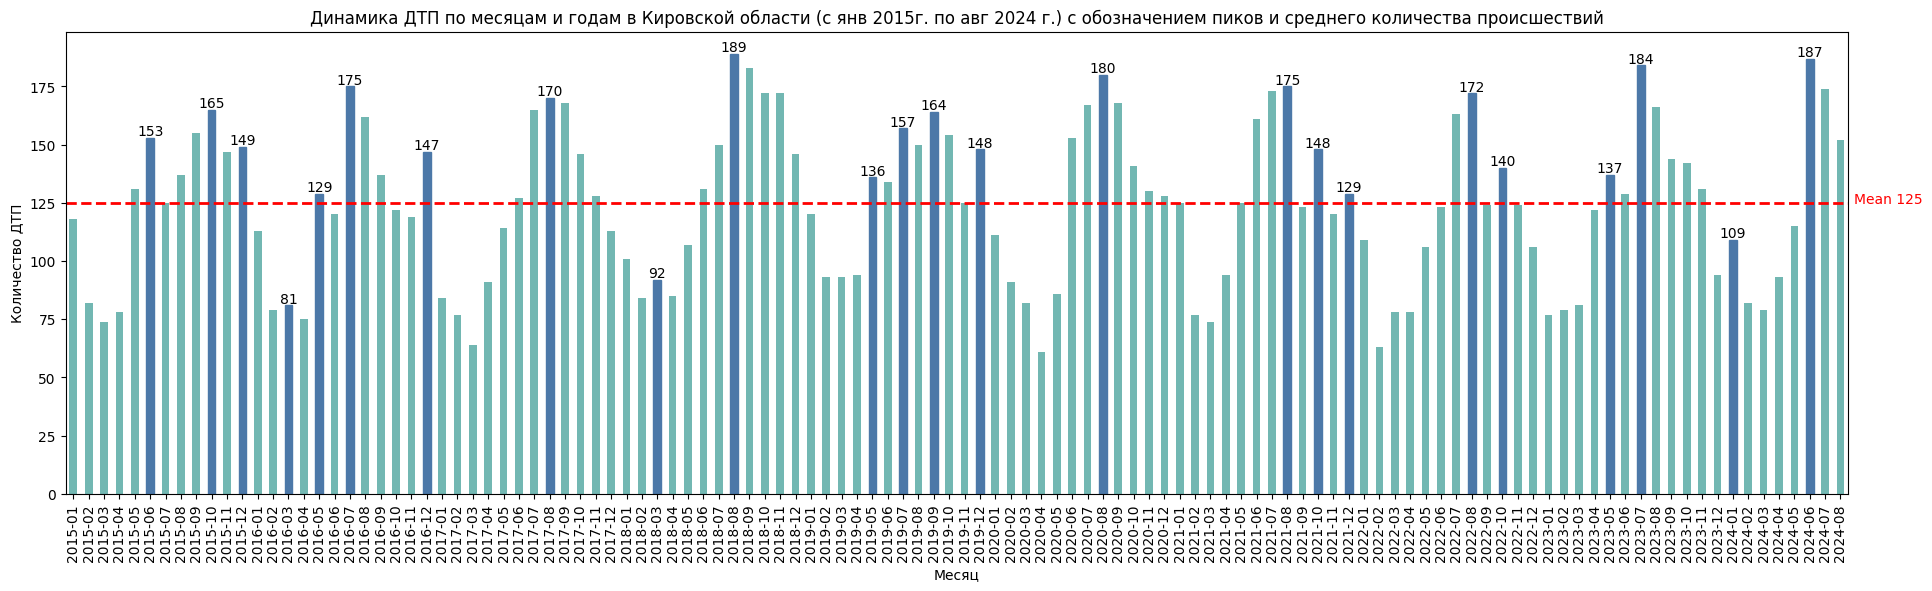

In [ ]:
fig, ax = plt.subplots(figsize=(23, 6))

# основной график
bars = df.plot.bar(color='#72B7B2', ax=ax)

values = df.values
peaks = (values > np.roll(values, 1)) & (values > np.roll(values, -1))

# просто перекрашиваем нужные столбцы
for i, bar in enumerate(ax.patches):
    if peaks[i]:
        bar.set_color('#4C78A8')

# подписи пиков
for i, v in enumerate(values):
    if peaks[i]:
        ax.text(i, v + 1, str(v),
                ha='center',
                color='black')

# среднее значение
mean_value1 = df.mean()

ax.axhline(
    y=mean_value1,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее значение: {mean_value1:.0f}'
)

ax.text(
    len(df) -0.1,
    mean_value1,
    f'Mean {mean_value1:.0f}',
    color='red')

ax.set_xlabel('Месяц')
ax.set_ylabel('Количество ДТП')
ax.set_title('Динамика ДТП по месяцам и годам в Кировской области (с янв 2015г. по авг 2024 г.) с обозначением пиков и среднего количества происшествий')

plt.xticks(rotation=90)
plt.show()

### 4.2 График по дням недели за весь период

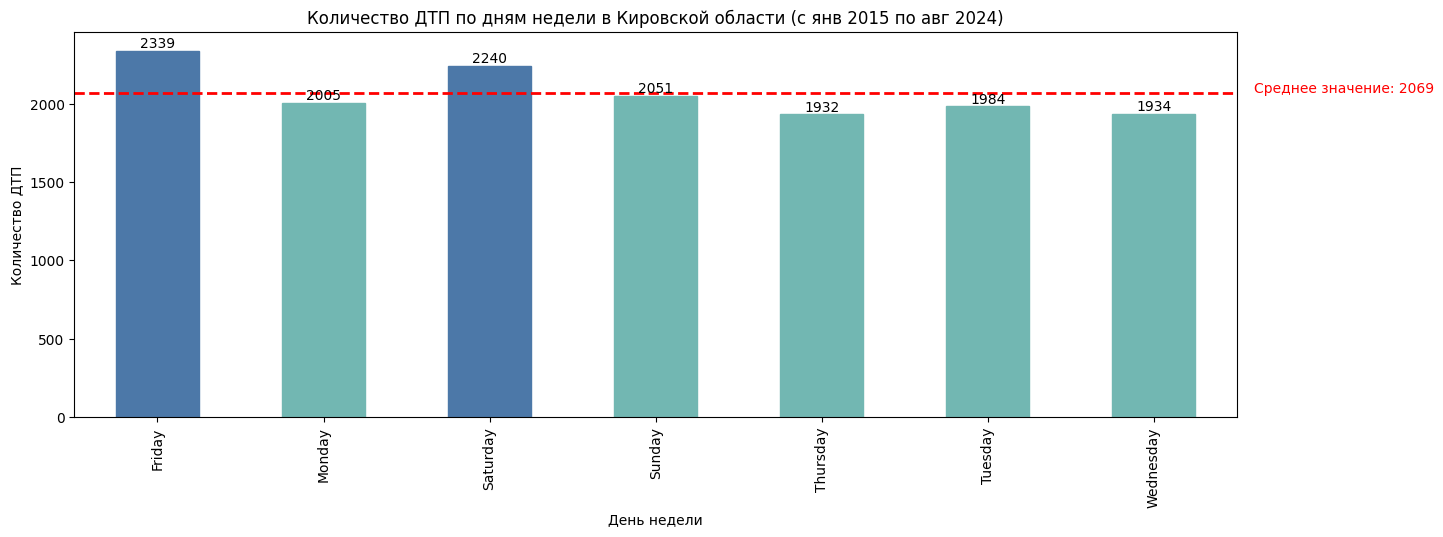

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))

df_week.plot.bar(ax=ax)

mean_value_week = df_week.mean()

# раскраска столбцов
for bar in ax.patches:
    if bar.get_height() >= mean_value_week:
        bar.set_color('#4C78A8')
    else:
        bar.set_color('#72B7B2')

# подписи
for container in ax.containers:
    ax.bar_label(container)

ax.axhline(
    y=mean_value_week,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее значение: {mean_value_week:.0f}'
)

ax.text(
    len(df_week) - 0.4,
    mean_value_week,
    f'Среднее значение: {mean_value_week:.0f}',
    color='red'
)

ax.set_xlabel('День недели')
ax.set_ylabel('Количество ДТП')
ax.set_title('Количество ДТП по дням недели в Кировской области (с янв 2015 по авг 2024)')

plt.xticks(rotation=90)
plt.show()

### 4.3 График по месяцам за весь период

In [ ]:
ko['month1'] = ko['datetime'].dt.month_name()
ko['year'] = ko['datetime'].dt.year

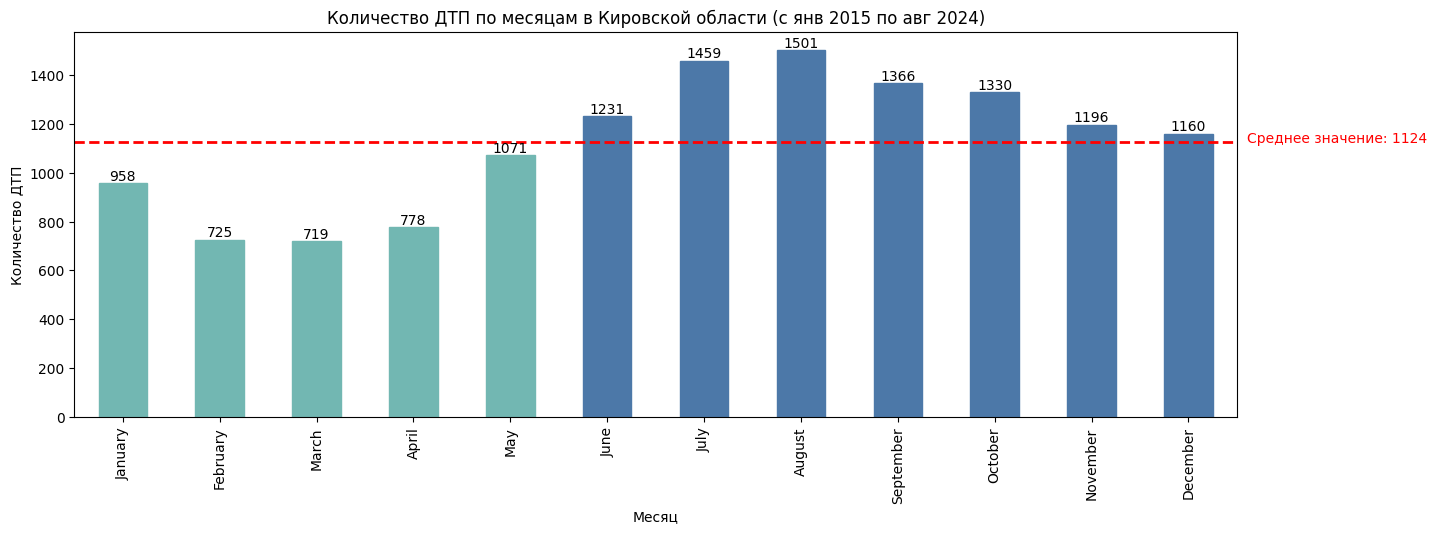

In [ ]:
# Месяц с мах кол-вом ДТП

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']

ko_m = ko[ko['year'] != 2024].groupby('month1')['id'].size().reindex(month_order)

mean_value2 = ko_m.mean()

# основной график
fig, ax = plt.subplots(figsize=(15,5))

ko_m.plot.bar(color='#72B7B2', ax=ax)


# раскраска столбцов
for bar in ax.patches:
    if bar.get_height() >= mean_value2:
        bar.set_color('#4C78A8')
    else:
        bar.set_color('#72B7B2')

# подписи
for container in ax.containers:
    ax.bar_label(container)

plt.axhline(
    y=mean_value2,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее количество ДТП: {mean_value2:.0f}')

plt.text(
    len(ko_m) -0.4,
    mean_value2,
    f'Среднее значение: {mean_value2:.0f}',
    color='red')

plt.xlabel('Месяц')
plt.ylabel('Количество ДТП')
plt.title('Количество ДТП по месяцам в Кировской области (с янв 2015 по авг 2024)')
plt.xticks(rotation=90);

### 4.4 График по годам за весь период

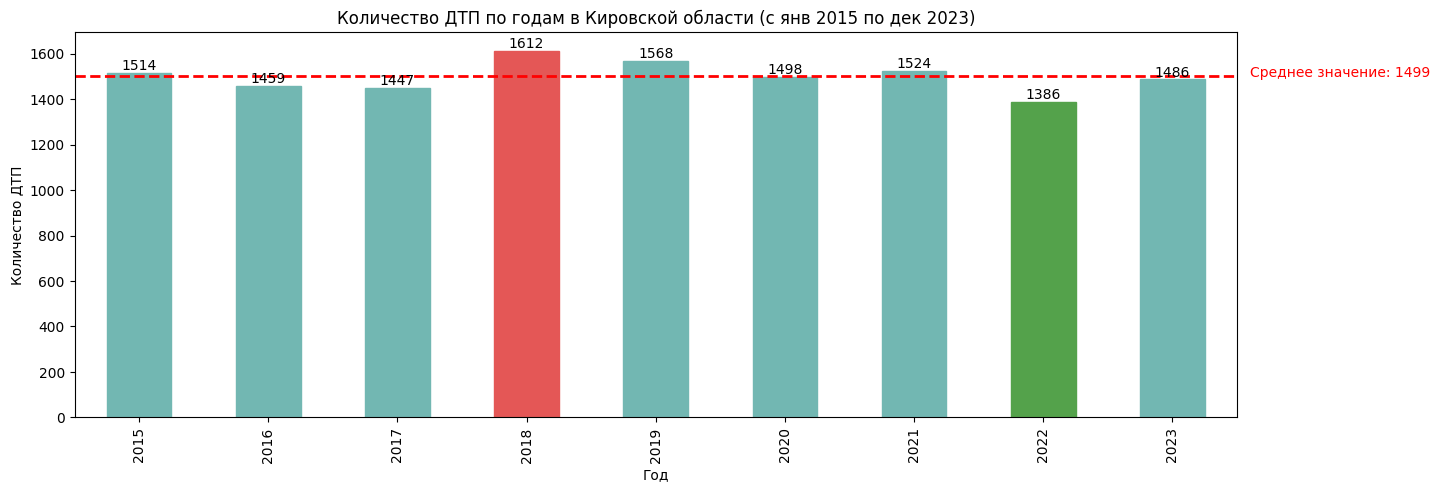

In [ ]:
# Год с мах кол-вом ДТП

ko_y = ko[ko['year'] != 2024].groupby('year')['id'].size()

mean_value_year = ko_y.mean()
max_value_year = ko_y.max()
min_value_year = ko_y.min()

# основной график
fig, ax = plt.subplots(figsize=(15,5))
ko_y.plot.bar(color='#72B7B2', ax=ax)

# раскраска столбцов
for bar in ax.patches:
    if bar.get_height() == min_value_year:
        bar.set_color('#54A24B')
    elif bar.get_height() == max_value_year:
        bar.set_color('#E45756')
    else:
        bar.set_color('#72B7B2')

# подписи
for container in ax.containers:
    ax.bar_label(container)

plt.axhline(
    y=mean_value_year,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Среднее количество ДТП: {mean_value_year:.0f}')

plt.text(
    len(ko_y) -0.4,
    mean_value_year,
    f'Среднее значение: {mean_value_year:.0f}',
    color='red')

plt.xlabel('Год')
plt.ylabel('Количество ДТП')
plt.title('Количество ДТП по годам в Кировской области (с янв 2015 по дек 2023)')
plt.xticks(rotation=90);

## 5. Сравнение количества ДТП между группами водителей с разным стажем в Кировской области

In [ ]:
a = participants_ko[(participants_ko['role']=='Водитель') & (participants_ko['years_of_driving_experience'] != 'стаж отсутствует')] \
    .groupby('years_of_driving_experience')['id'].size()

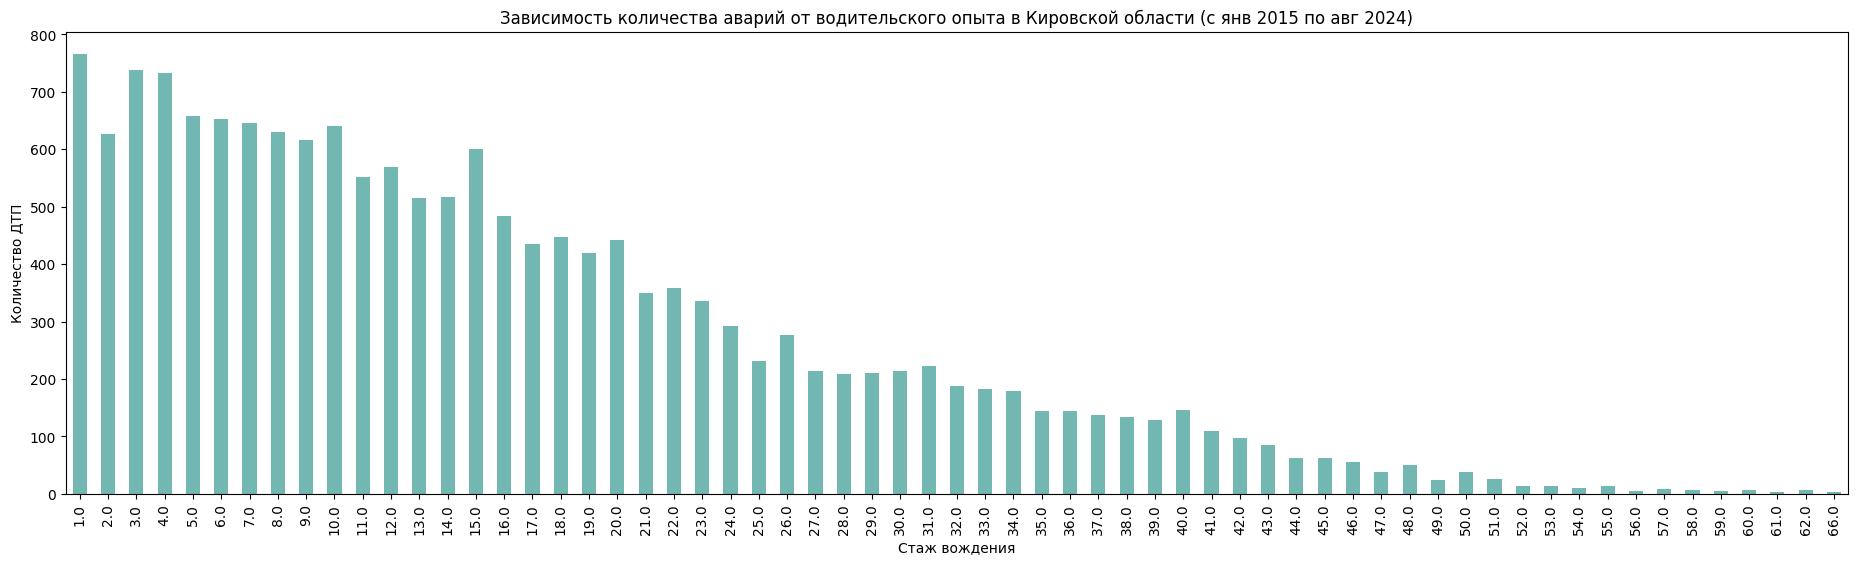

In [ ]:
plt.figure(figsize=(13,6))

a.plot.bar(figsize=(23,6), color='#72B7B2')

plt.xlabel('Стаж вождения')
plt.ylabel('Количество ДТП')
plt.title('Зависимость количества аварий от водительского опыта в Кировской области (с янв 2015 по авг 2024)')
plt.xticks(rotation=90);